<a href="https://colab.research.google.com/github/Sj-kronton/IA_2025/blob/main/arboles.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

AGENDA

1. Se haran cosas con un data set
2. exploracion de datos EDA
3. Limpieza de datos
4. Entrenar el modelo (arbol de decision)
5. Evaluar el modelo

In [35]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split #partir el dataset
from sklearn.tree import DecisionTreeRegressor #modelo de arbol
from sklearn.tree import plot_tree #dibujar arbol
from sklearn.tree import export_graphviz
from sklearn.tree import export_text
from sklearn import metrics
from sklearn.metrics import mean_squared_error, r2_score

#OBJETIVO

crear y evaluar un modelo de arbol de decision para predecir las ventas con datos simulados de una empresa, dependiendo de las inversiones realizadas en publicidad

In [36]:
datos=pd.read_csv('https://raw.githubusercontent.com/rpizarrog/Analisis-Inteligente-de-datos/main/datos/Advertising_Web.csv')
datos.head()

,Unnamed: 0,X,TV,Radio,Newspaper,Web,Sales
0,1,1,230.1,37.8,69.2,306.634752,22.1
1,2,2,44.5,39.3,45.1,302.653070,10.4
2,3,3,17.2,45.9,69.3,49.498908,9.3
3,4,4,151.5,41.3,58.5,257.816893,18.5
4,5,5,180.8,10.8,58.4,195.660076,12.9


In [37]:
df=pd.DataFrame(datos) #crear datafrme y buscar las variables dpeendientes e independientes
df.head()

,Unnamed: 0,X,TV,Radio,Newspaper,Web,Sales
0,1,1,230.1,37.8,69.2,306.634752,22.1
1,2,2,44.5,39.3,45.1,302.653070,10.4
2,3,3,17.2,45.9,69.3,49.498908,9.3
3,4,4,151.5,41.3,58.5,257.816893,18.5
4,5,5,180.8,10.8,58.4,195.660076,12.9


/tmp/ipython-input-2657983762.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


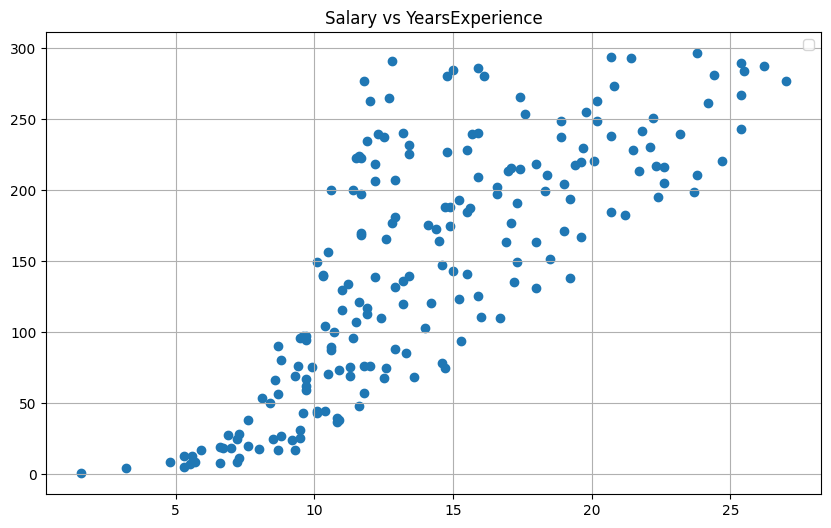

In [38]:
x=df["Sales"] #variables dependientes e independientes
y=df["TV"]#esta es la dependiente

plt.figure(figsize=(10,6))
plt.scatter(x,y)
plt.title("Salary vs YearsExperience")
plt.legend()
plt.grid(True)
plt.show()

Text(0.5, 1.0, 'TV vs Sales')

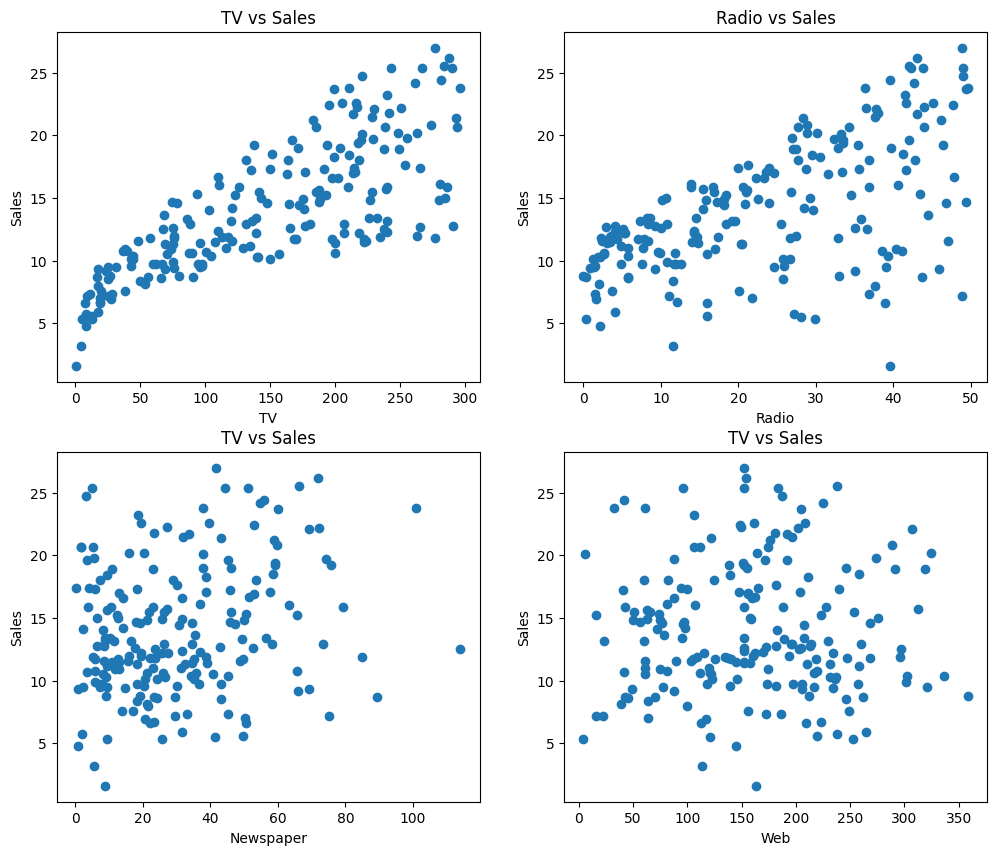

In [39]:
fig,axes=plt.subplots(nrows=2,ncols=2,figsize=(12,10))

axes[0,0].scatter(df["TV"],df["Sales"])
axes[0,0].set_xlabel("TV")
axes[0,0].set_ylabel("Sales")
axes[0,0].set_title("TV vs Sales")

axes[0,1].scatter(df["Radio"],df["Sales"])
axes[0,1].set_xlabel("Radio")
axes[0,1].set_ylabel("Sales")
axes[0,1].set_title("Radio vs Sales")

axes[1,0].scatter(df["Newspaper"],df["Sales"])
axes[1,0].set_xlabel("Newspaper")
axes[1,0].set_ylabel("Sales")
axes[1,0].set_title("TV vs Sales")

axes[1,1].scatter(df["Web"],df["Sales"])
axes[1,1].set_xlabel("Web")
axes[1,1].set_ylabel("Sales")
axes[1,1].set_title("TV vs Sales")

##Exploracion de datos EDA

In [40]:
print("Observaciones y variables: ", datos.shape)

Observaciones y variables:  (200, 7)


In [41]:
datos.dtypes

,0
Unnamed: 0,int64
X,int64
TV,float64
Radio,float64
Newspaper,float64
Web,float64
Sales,float64


In [42]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   X           200 non-null    int64  
 2   TV          200 non-null    float64
 3   Radio       200 non-null    float64
 4   Newspaper   200 non-null    float64
 5   Web         200 non-null    float64
 6   Sales       200 non-null    float64
dtypes: float64(5), int64(2)
memory usage: 11.1 KB


Se describen las variables como variables independientes TV, Radio, Newspaper Y Web
y como variable dependiente Sales.

Independientes:
* Tv: costos de publicidad en TV (miles de dolares)
* Radio: costos de publicidad inestidos en medios de difusion radio (miles de dolares)
* Newspaper: costos publicitarios para medios impresos (miles de dolares)
* Web: costos publicitarios en eherramientas digitales (miles de dolares)

In [43]:
datos.head()

,Unnamed: 0,X,TV,Radio,Newspaper,Web,Sales
0,1,1,230.1,37.8,69.2,306.634752,22.1
1,2,2,44.5,39.3,45.1,302.653070,10.4
2,3,3,17.2,45.9,69.3,49.498908,9.3
3,4,4,151.5,41.3,58.5,257.816893,18.5
4,5,5,180.8,10.8,58.4,195.660076,12.9


##Limpieza de datos

In [44]:
#eliminar columnas inecesarias
datos=datos[["TV", "Radio", "Newspaper", "Web", "Sales"]] #limpiar columnas creando un nuevo dataset con solo los datos necesarios
datos.describe() #calculos basicos de porcentaje

,TV,Radio,Newspaper,Web,Sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,159.587355,14.022500
std,85.854236,14.846809,21.778621,76.815266,5.217457
min,0.700000,0.000000,0.300000,4.308085,1.600000
25%,74.375000,9.975000,12.750000,99.048767,10.375000
50%,149.750000,22.900000,25.750000,156.862154,12.900000
75%,218.825000,36.525000,45.100000,212.311848,17.400000
max,296.400000,49.600000,114.000000,358.247042,27.000000


##Datos de entrenamiento y datos de validacion (Entrenamiento de modelo)

Se usara la semilla 1279 (random_state=2022)
Los datos se distribuiran de la siguiente maneral:
* 70% para entrenamiento
* 30% para validacion del modelo

In [45]:
X_entrena, X_valida, Y_entrena, Y_valida = train_test_split(datos.drop(columns="Sales"), datos["Sales"],train_size=.7) #,random_state=1279

In [46]:
X_entrena.shape #estructura de datos de entrenamiento

(140, 4)

##Modelando el arbol de decision

La clase DecisionTreeRegressor del modulo sklearn.tree tiene los siguientes parametros:
* max_depth: profundidad maxima que puede alcanzar el arbol.
* min_samples_split: numero minimo de observaciones que debe de tener el nodo para que pueda dividirse, si es decimal se interpreta como la fraccion total de observaciones de entrenamiento (min_samples_split*n_samples)
* min_samples_leaf: numero minimo de observaciones que debe de tener cada uno de los nodos hijos para que se produzca la division
* max_leaf_nodes: numero maximo de nodos terminales
* random_seed: semilla que permite resultados reproducibles
**Es un valor entero**

In [47]:
modelo_ar=DecisionTreeRegressor(max_depth=3) #el random state corresponde a la semilla ,random_state=2022 NOTA: SIEMPRE ADJUNTAR QUE SEMILLA SE USA AL MOMENTO DE HACER REPORTE O UNA TAREA

usamos los datos del entrenamiento con el modelo del arbol de regresion

In [48]:
modelo_ar.fit(X_entrena, Y_entrena)

DecisionTreeRegressor(max_depth=3)

##Visualizacion del modelo


In [49]:
print("Profundidad del arbol: ", modelo_ar.get_depth())
print("Numero de nodos terminales: ", modelo_ar.get_n_leaves())

Profundidad del arbol:  3
Numero de nodos terminales:  8


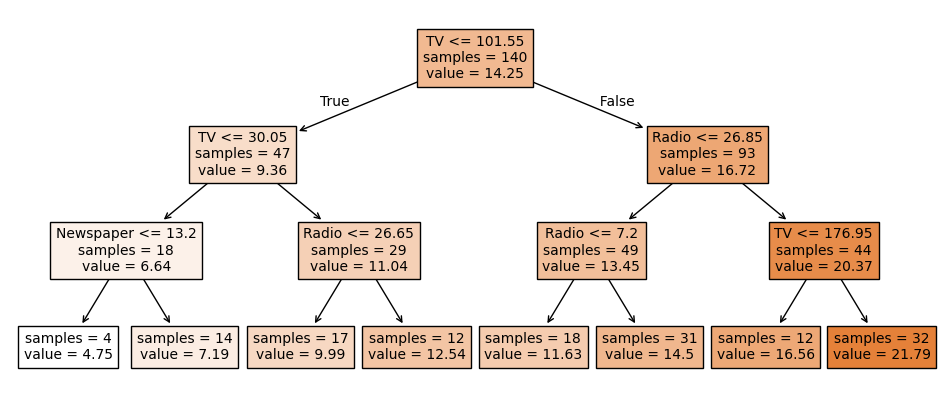

In [50]:
fig,ax=plt.subplots(figsize=(12,5))
plot=plot_tree(
    decision_tree=modelo_ar,
    feature_names=datos.drop(columns="Sales").columns,
    filled=True,
    impurity=False,
    fontsize=10,
    precision=2,
    ax=ax
)

In [51]:
texto_modelo=export_text(
    decision_tree=modelo_ar,
    feature_names=datos.drop(columns="Sales").columns
) #el arbol pero en texto en lugar de en un modelo
print(texto_modelo)

|--- TV <= 101.55
|   |--- TV <= 30.05
|   |   |--- Newspaper <= 13.20
|   |   |   |--- value: [4.75]
|   |   |--- Newspaper >  13.20
|   |   |   |--- value: [7.19]
|   |--- TV >  30.05
|   |   |--- Radio <= 26.65
|   |   |   |--- value: [9.99]
|   |   |--- Radio >  26.65
|   |   |   |--- value: [12.54]
|--- TV >  101.55
|   |--- Radio <= 26.85
|   |   |--- Radio <= 7.20
|   |   |   |--- value: [11.63]
|   |   |--- Radio >  7.20
|   |   |   |--- value: [14.50]
|   |--- Radio >  26.85
|   |   |--- TV <= 176.95
|   |   |   |--- value: [16.56]
|   |   |--- TV >  176.95
|   |   |   |--- value: [21.79]



##Evaluar la importancia de las predicciones

la importancia de cada predictor en el modelo se calcula como la reduccion total normalizada en el criterio de division. En este caso, el mse que consigue el predictor en las divisiones en las que participa. Si un predictor no se ha seleccionado en ninguna division, no se inlcuye en el modelo y su importancia es de 0

In [52]:
importancia_predictores=pd.DataFrame(
    {
        "predictor":datos.drop(columns="Sales").columns,
        "importancia":modelo_ar.feature_importances_
    }

)

In [53]:
importancia_predictores.sort_values(by="importancia", ascending=False)

,predictor,importancia
0,TV,0.628526
1,Radio,0.366068
2,Newspaper,0.005406
3,Web,0.000000
